# Regresión Discontinua en el Tiempo (RDiT)

Este notebook empieza con una base ya preparada por **preRDiT**.

Aquí no se construyen variables de preparación. RDiT se concentra en estimación, sensibilidad, placebo e interpretación.

## RDiT-01 — Leer la base preparada

In [ ]:
import pandas as pd

# Base ya preparada por preRDiT: sin fechas crudas, con dias_relativos
# y post_declaracion ya construidas.
url_rdit = "https://github.com/doctorado-cuanticp/rdit/raw/main/rdit_preparado.csv"
rdit = pd.read_csv(url_rdit)

In [4]:

rdit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_proyecto          90 non-null     object        
 1   fecha_votacion       90 non-null     datetime64[ns]
 2   fecha_declaracion    90 non-null     datetime64[ns]
 3   pct_apoyo_oposicion  90 non-null     float64       
 4   asistencia_pleno     90 non-null     float64       
 5   tramite_urgencia     90 non-null     int64         
 6   dias_relativos       90 non-null     int64         
 7   post_declaracion     90 non-null     int64         
dtypes: datetime64[ns](2), float64(2), int64(3), object(1)
memory usage: 5.8+ KB


In [5]:
rdit.head()

,id_proyecto,fecha_votacion,fecha_declaracion,pct_apoyo_oposicion,asistencia_pleno,tramite_urgencia,dias_relativos,post_declaracion
0,PL-001,2026-03-01,2026-05-15,57.2,90.2,0,-75,0
1,PL-002,2026-03-02,2026-05-15,56.6,83.7,0,-74,0
2,PL-003,2026-03-06,2026-05-15,44.1,81.0,0,-70,0
3,PL-004,2026-03-08,2026-05-15,48.9,90.6,0,-68,0
4,PL-005,2026-03-10,2026-05-15,52.8,85.1,0,-66,0


## RDiT-02 — Observar el patrón alrededor del corte

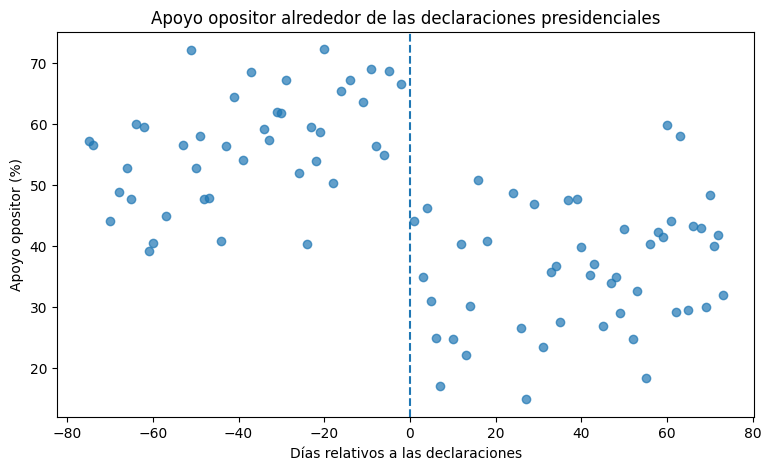

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.scatter(rdit["dias_relativos"], rdit["pct_apoyo_oposicion"], alpha=0.7)
plt.axvline(0, linestyle="--")
plt.xlabel("Días relativos a las declaraciones")
plt.ylabel("Apoyo opositor (%)")
plt.title("Apoyo opositor alrededor de las declaraciones presidenciales")
plt.show()

## RDiT-03 — Seleccionar una ventana de ±60 días

In [7]:
rdit_60 = rdit[rdit["dias_relativos"].between(-60, 60)].copy()
print("Número de observaciones:", len(rdit_60))

Número de observaciones: 70


## RDiT-04 — Estimar la discontinuidad

In [8]:
import statsmodels.formula.api as smf

modelo = smf.ols(
    "pct_apoyo_oposicion ~ post_declaracion + dias_relativos + post_declaracion:dias_relativos",
    data=rdit_60
).fit()

## RDiT-05 — Leer el resultado principal

In [9]:
tau = modelo.params["post_declaracion"]
p_tau = modelo.pvalues["post_declaracion"]

print("Cambio inmediato estimado:", round(tau, 2), "puntos porcentuales")
print("p-valor:", round(p_tau, 4))

Cambio inmediato estimado: -32.61 puntos porcentuales
p-valor: 0.0


## RDiT-06 — Visualizar el ajuste

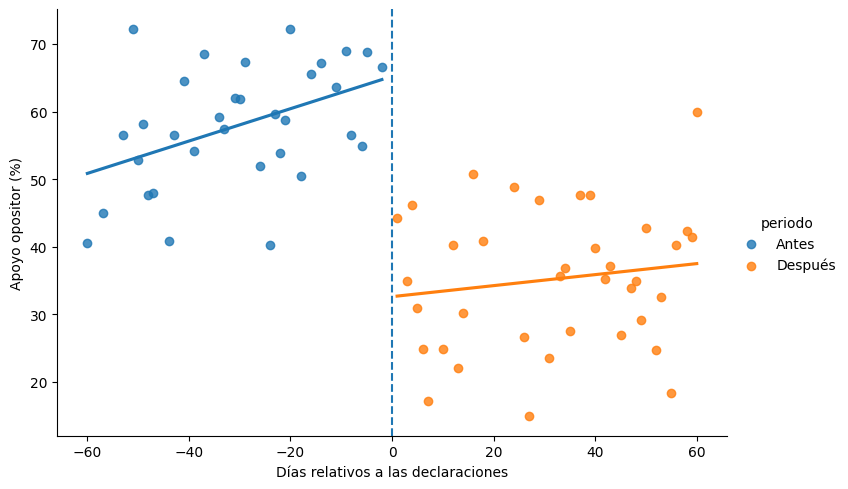

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

rdit_60["periodo"] = rdit_60["post_declaracion"].map({0: "Antes", 1: "Después"})

sns.lmplot(
    data=rdit_60,
    x="dias_relativos",
    y="pct_apoyo_oposicion",
    hue="periodo",
    ci=None,
    height=5,
    aspect=1.5
)

plt.axvline(0, linestyle="--")
plt.xlabel("Días relativos a las declaraciones")
plt.ylabel("Apoyo opositor (%)")
plt.show()

## RDiT-07 — Sensibilidad a distintas ventanas

In [ ]:
for ventana in [45, 60, 75]:
    datos = rdit[rdit["dias_relativos"].between(-ventana, ventana)].copy()
    modelo_temp = smf.ols(
        "pct_apoyo_oposicion ~ post_declaracion + dias_relativos + post_declaracion:dias_relativos",
        data=datos
    ).fit()

    print(
        "Ventana:", f"±{ventana}",
        "| N:", len(datos),
        "| cambio inmediato:", round(modelo_temp.params["post_declaracion"], 2),
        "| p:", round(modelo_temp.pvalues["post_declaracion"], 4)
    )
# Repetimos con un barrido continuo de ventanas para ver si el resultado
# depende de haber elegido justo 45, 60 y 75 días.
ventanas_finas = range(30, 91, 2)
coefs, lo, hi = [], [], []

for v in ventanas_finas:
    datos = rdit[rdit["dias_relativos"].between(-v, v)].copy()
    m = smf.ols(
        "pct_apoyo_oposicion ~ post_declaracion + dias_relativos + post_declaracion:dias_relativos",
        data=datos
    ).fit()
    coefs.append(m.params["post_declaracion"])
    ci = m.conf_int().loc["post_declaracion"]
    lo.append(ci[0]); hi.append(ci[1])

plt.figure(figsize=(8, 4.5))
plt.plot(list(ventanas_finas), coefs, color="tab:blue")
plt.fill_between(list(ventanas_finas), lo, hi, alpha=0.2, color="tab:blue")
plt.axhline(0, linestyle="--", color="gray")
for v in [45, 60, 75]:
    plt.axvline(v, linestyle=":", color="gray", alpha=0.6)
plt.xlabel("Ancho de la ventana (± días)")
plt.ylabel("Cambio inmediato estimado")
plt.title("Estabilidad del resultado según el ancho de la ventana")
plt.show()
# La banda sombreada es el intervalo de confianza. Si en algún punto tocara
# la línea de cero, esa ventana ya no permitiría rechazar H0.

## RDiT-08 — Placebo: asistencia al pleno

In [12]:
modelo_placebo = smf.ols(
    "asistencia_pleno ~ post_declaracion + dias_relativos + post_declaracion:dias_relativos",
    data=rdit_60
).fit()

tau_placebo = modelo_placebo.params["post_declaracion"]
p_placebo = modelo_placebo.pvalues["post_declaracion"]

print("Cambio inmediato en asistencia:", round(tau_placebo, 2))
print("p-valor:", round(p_placebo, 4))

Cambio inmediato en asistencia: -2.22
p-valor: 0.1355
